In [20]:
import numpy as np
import pandas as pd 
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import datetime
from sklearn.preprocessing import MinMaxScaler

In [21]:
data = pd.read_csv('AMZN.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
history_years = 5
cutoff_date = data['Date'].max() - pd.DateOffset(years=history_years)
data = data[data['Date'] >= cutoff_date].copy()
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
data = data[['Date'] + feature_cols].copy()
data.head()


,Date,Open,High,Low,Close,Volume
5256,2018-04-05,72.099503,72.977997,71.353500,72.587502,128270000
5257,2018-04-06,71.498497,72.625000,70.013000,70.261497,117646000
5258,2018-04-09,71.251503,71.924004,70.128502,70.304001,84164000
5259,2018-04-10,71.599503,71.918999,70.785004,71.810997,85082000
5260,2018-04-11,71.972000,72.439003,71.244499,71.352501,71650000


In [22]:

data = data[['Date'] + feature_cols].copy()
data.head()


,Date,Open,High,Low,Close,Volume
5256,2018-04-05,72.099503,72.977997,71.353500,72.587502,128270000
5257,2018-04-06,71.498497,72.625000,70.013000,70.261497,117646000
5258,2018-04-09,71.251503,71.924004,70.128502,70.304001,84164000
5259,2018-04-10,71.599503,71.918999,70.785004,71.810997,85082000
5260,2018-04-11,71.972000,72.439003,71.244499,71.352501,71650000


In [23]:
try:
    if torch.cuda.is_available():
        device = torch.device('cuda:0')
        _ = torch.zeros(1, device=device)
        print('Using CUDA')
    else:
        device = torch.device('cpu')
        print('Using CPU')
except Exception:
    device = torch.device('cpu')
    print('CUDA unavailable; using CPU')

device

Using CPU


device(type='cpu')

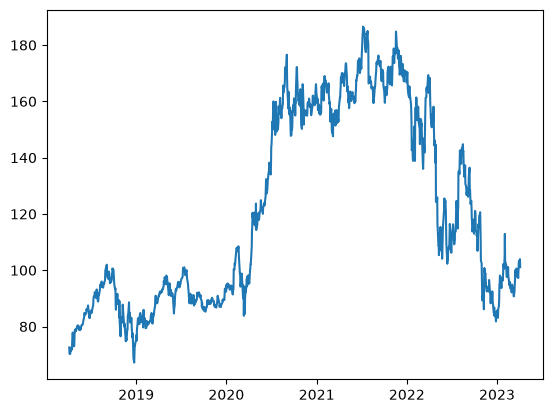

In [24]:
data['Date'] = pd.to_datetime(data['Date'])
plt.plot(data['Date'], data['Close'])

In [25]:
from copy import deepcopy as dc

def build_windows(df, window_size):
    df = dc(df).copy().sort_values('Date').reset_index(drop=True)
    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    close_scaler = MinMaxScaler(feature_range=(0, 1))

    scaled = feature_scaler.fit_transform(df[feature_cols].to_numpy(dtype=np.float32))
    close_scaler.fit(df['Close'].to_numpy(dtype=np.float32).reshape(-1, 1))

    X = []
    y = []
    for i in range(window_size, len(scaled)):
        X.append(scaled[i - window_size:i])
        y.append(scaled[i, feature_cols.index('Close')])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32).reshape(-1, 1)
    return X, y, feature_scaler, close_scaler

window_size = 30
X, y, feature_scaler, close_scaler = build_windows(data, window_size)
X.shape, y.shape


((1230, 30, 5), (1230, 1))

In [26]:

X.shape, y.shape


((1230, 30, 5), (1230, 1))

In [27]:
split_index = int(len(X) * 0.8)
split_index


984

In [28]:
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((984, 30, 5), (246, 30, 5), (984, 1), (246, 1))

In [29]:
X_train = X_train.reshape((-1, window_size, len(feature_cols)))
X_test = X_test.reshape((-1, window_size, len(feature_cols)))

y_train = y_train.reshape((-1, 1))
y_test = y_test.reshape((-1, 1))

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((984, 30, 5), (246, 30, 5), (984, 1), (246, 1))

In [30]:
X_train = torch.tensor(X_train.astype(np.float32))
X_test = torch.tensor(X_test.astype(np.float32))

y_train = torch.tensor(y_train.astype(np.float32))
y_test = torch.tensor(y_test.astype(np.float32))

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


(torch.Size([984, 30, 5]),
 torch.Size([246, 30, 5]),
 torch.Size([984, 1]),
 torch.Size([246, 1]))

In [31]:
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = X
            self.y = y
        def __len__(self):
         return len(self.X)
        def __getitem__(self, i):
            return self.X[i], self.y[i]
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

In [32]:
train_dataset

In [33]:
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using the already-trained model.


Full 5-year span: 0.0 to 4.884325804243669
First 5 actual prices: [79.088  78.7185 79.273  79.07   80.093 ]
First 5 predicted prices: [82.31149 82.32327 82.29817 82.27953 82.29141]
RMSE approx: 5.253763675689697


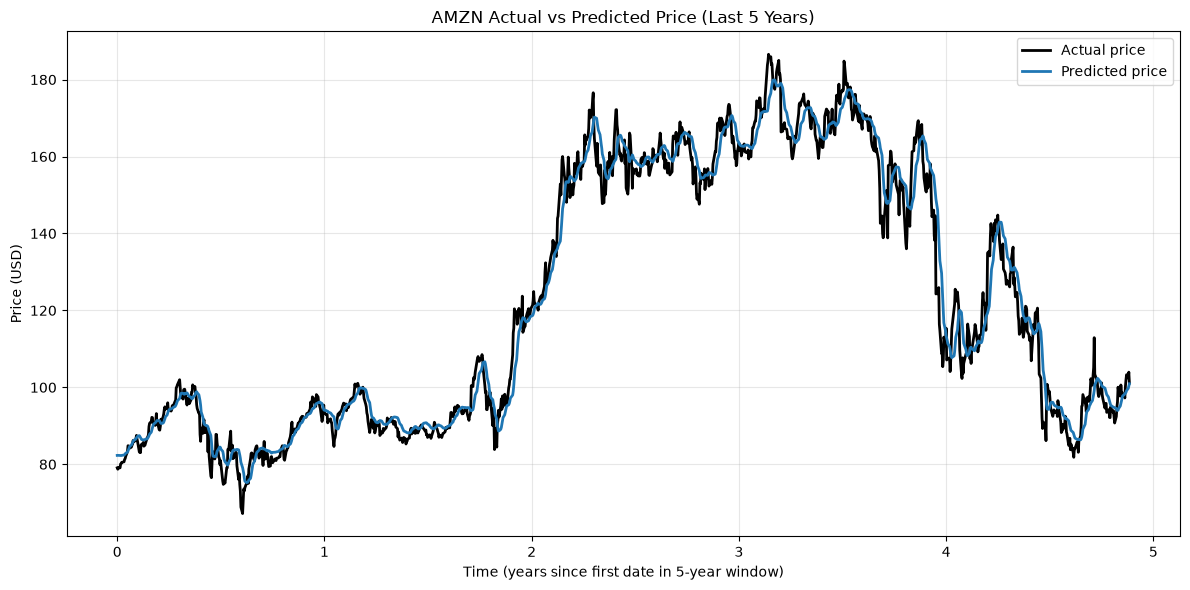

In [34]:

if 'model' not in globals():
    class LSTM(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])

    model = LSTM(input_size=len(feature_cols), hidden_size=64, num_layers=2).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(180):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 25 == 0:
            print(f'Epoch {epoch + 1}/180, Loss: {loss.item():.6f}')
else:
    print('Using the already-trained model.')

model.eval()
with torch.no_grad():
    full_pred = model(torch.tensor(X.astype(np.float32)).to(device)).cpu().numpy().reshape(-1)
    full_actual = y.reshape(-1)

actual_prices = close_scaler.inverse_transform(full_actual.reshape(-1, 1)).flatten()
predicted_prices = close_scaler.inverse_transform(full_pred.reshape(-1, 1)).flatten()

plot_dates = data['Date'].iloc[window_size:]
plot_years = ((plot_dates - plot_dates.min()).dt.total_seconds() / (365.25 * 24 * 60 * 60)).to_numpy()

print('Full 5-year span:', plot_years.min(), 'to', plot_years.max())
print('First 5 actual prices:', actual_prices[:5])
print('First 5 predicted prices:', predicted_prices[:5])
print('RMSE approx:', float(np.sqrt(np.mean((actual_prices - predicted_prices) ** 2))))

plt.figure(figsize=(12, 6))
plt.plot(plot_years, actual_prices, label='Actual price', color='black', linewidth=2)
plt.plot(plot_years, predicted_prices, label='Predicted price', color='tab:blue', linewidth=2)
plt.title('AMZN Actual vs Predicted Price (Last 5 Years)')
plt.xlabel('Time (years since first date in 5-year window)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
